In [1]:
import pandas as pd
import numpy as np
import optuna
import lightgbm as lgb
from optuna.integration import LightGBMPruningCallback
from plotly.io import show
import optuna.visualization as ov
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#importing datasets
df = pd.read_csv("train.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [3]:
df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
object_df = df.select_dtypes(include=[np.object_])
object_df.nunique()

gender               3
ethnicity            5
education_level      4
income_level         5
smoking_status       3
employment_status    4
dtype: int64

In [5]:
unique_values = object_df.apply(lambda x: x.unique())
print(unique_values)

gender                                         [Female, Male, Other]
ethnicity                     [Hispanic, White, Asian, Black, Other]
education_level      [Highschool, Graduate, Postgraduate, No formal]
income_level         [Lower-Middle, Upper-Middle, Low, Middle, High]
smoking_status                              [Current, Never, Former]
employment_status           [Employed, Retired, Student, Unemployed]
dtype: object


In [6]:
income_level_to_value = {'Lower-Middle' : 2, 'Upper-Middle':4, 'Low': 1, 'Middle':3, 'High':5}
df['income_level'] = df['income_level'].map(income_level_to_value)

In [7]:
#remove outlier
numeric_cols = df.select_dtypes(include=["float", "int"]).columns.tolist()

for col in numeric_cols:
    Q1 = df[col].quantile(0.2)
    Q3 = df[col].quantile(0.8)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    df[col] = np.where(df[col].between(lower, upper), df[col], np.nan)

df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 453333 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  453333 non-null  float64
 1   age                                 453333 non-null  float64
 2   alcohol_consumption_per_week        453333 non-null  float64
 3   physical_activity_minutes_per_week  453333 non-null  float64
 4   diet_score                          453333 non-null  float64
 5   sleep_hours_per_day                 453333 non-null  float64
 6   screen_time_hours_per_day           453333 non-null  float64
 7   bmi                                 453333 non-null  float64
 8   waist_to_hip_ratio                  453333 non-null  float64
 9   systolic_bp                         453333 non-null  float64
 10  diastolic_bp                        453333 non-null  float64
 11  heart_rate                     

algoritmo di ml che assegna male/female a other

In [8]:
#clean column
df_gender = df.copy()
df_gender = df_gender.drop(['diagnosed_diabetes', 'family_history_diabetes'], axis=1)

#Select only rows that contain “male” or “female”
df_train = df_gender[df_gender["gender"].isin(["Male", "Female"])]
df_other = df_gender[df_gender["gender"] == "Other"]

#X = all columns except gender
X = df_train.drop(columns=["gender"])
X = pd.get_dummies(X, drop_first=True)

#y = gender as a label
y = df_train["gender"]

#train
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

#prediction of “others”
X_other = df_other.drop(columns=["gender"])
X_other = pd.get_dummies(X_other, drop_first=True)

#Align columns and replace missing values with 0
X_other = X_other.reindex(columns=X.columns, fill_value=0)

preds = model.predict(X_other)

#only updating the “other” items
df.loc[df["gender"] == "Other", "gender"] = preds

print(df["gender"].unique())

['Female' 'Male']


In [9]:
df = pd.get_dummies(df, drop_first=True)

with pd.option_context('display.max_columns', None):
    display(df.head())
df.describe().T

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,income_level,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes,gender_Male,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,education_level_Highschool,education_level_No formal,education_level_Postgraduate,smoking_status_Former,smoking_status_Never,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,0.0,31.0,1.0,45.0,7.7,6.8,6.1,33.4,0.93,112.0,70.0,62.0,199.0,58.0,114.0,102.0,2.0,0.0,0.0,0.0,1.0,False,False,True,False,False,True,False,False,False,False,False,False,False
1,1.0,50.0,2.0,73.0,5.7,6.5,5.8,23.8,0.83,120.0,77.0,71.0,199.0,50.0,121.0,124.0,4.0,0.0,0.0,0.0,1.0,False,False,False,False,True,True,False,False,False,True,False,False,False
2,2.0,32.0,3.0,158.0,8.5,7.4,9.1,24.1,0.83,95.0,89.0,73.0,188.0,59.0,114.0,108.0,2.0,0.0,0.0,0.0,0.0,True,False,True,False,False,True,False,False,False,True,True,False,False
5,5.0,42.0,1.0,100.0,4.4,6.4,5.3,25.5,0.84,111.0,67.0,77.0,174.0,42.0,101.0,95.0,2.0,0.0,0.0,0.0,0.0,False,False,False,False,True,True,False,False,False,True,True,False,False
6,6.0,41.0,2.0,148.0,3.4,5.6,3.7,27.9,0.89,130.0,77.0,73.0,168.0,41.0,106.0,137.0,2.0,0.0,0.0,0.0,1.0,False,False,False,False,True,False,False,False,False,False,False,False,False


,count,mean,std,min,25%,50%,75%,max
id,453333.0,349508.676851,201690.488585,0.00,175063.00,349396.00,524146.00,699999.00
age,453333.0,49.121434,11.488908,19.00,41.00,49.00,57.00,89.00
alcohol_consumption_per_week,453333.0,2.068991,1.039909,1.00,1.00,2.00,3.00,6.00
physical_activity_minutes_per_week,453333.0,74.177108,34.647334,1.00,48.00,70.00,94.00,191.00
diet_score,453333.0,5.968547,1.461232,1.00,5.00,6.00,7.00,9.90
sleep_hours_per_day,453333.0,6.999799,0.901182,3.90,6.40,7.00,7.60,9.90
screen_time_hours_per_day,453333.0,6.003794,2.015460,0.60,4.60,6.00,7.40,12.80
bmi,453333.0,25.872785,2.806171,16.30,23.90,25.90,27.80,35.50
waist_to_hip_ratio,453333.0,0.858817,0.037434,0.74,0.83,0.86,0.88,0.98
systolic_bp,453333.0,115.687700,10.922850,91.00,108.00,116.00,123.00,154.00


In [10]:
print(df["diagnosed_diabetes"].unique())

[1. 0.]


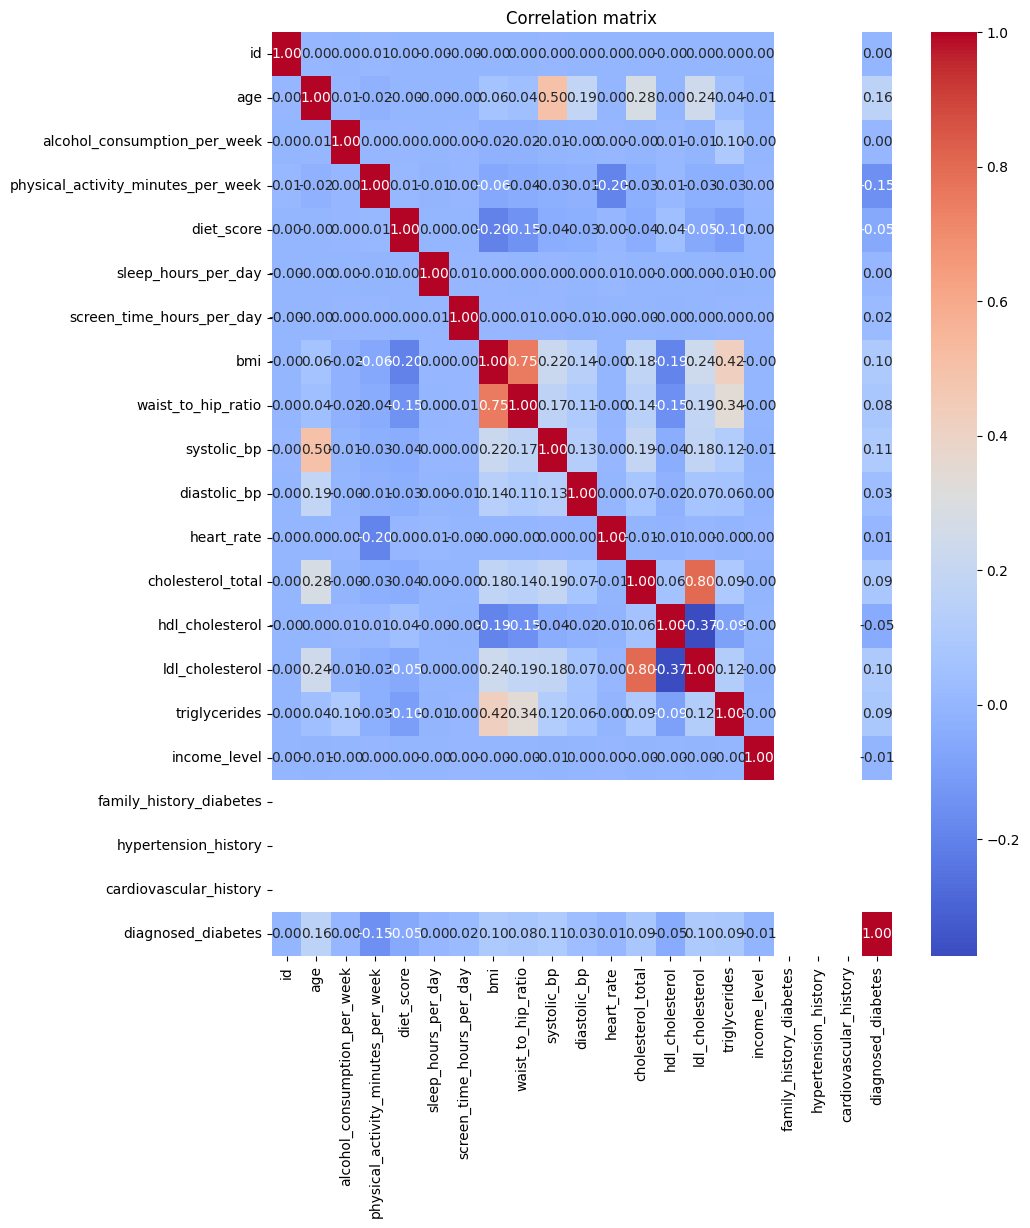

In [11]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 12))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix')
plt.show()



### 1. Indicators of Insulin Resistance and Lipid Risk (Essential)

The standard lipid profile (Total, HDL, LDL, Triglycerides) is useful, but in type 2 diabetes, “diabetic dyslipidemia” is a specific condition. Here’s what to calculate:

* **Triglycerides/HDL Ratio ($TG/HDL Ratio$)**
    * **Formula:** $\frac{\text{triglycerides}}{\text{hdl\_cholesterol}}$
    * **Clinical significance:** It is one of the most powerful surrogate markers of **insulin resistance**. A high value (generally $> 2.5$ or $3.0$ if in mg/dL) is strongly correlated with small, dense (more dangerous) LDL particles and hyperinsulinemia, even before diabetes is diagnosed.
* **Non-HDL Cholesterol**
    * **Formula:** $\text{total cholesterol} - \text{hdl\_cholesterol}$
    * **Clinical significance:** Current diabetes guidelines consider this a crucial secondary therapeutic target. It represents all “bad” cholesterol (LDL + VLDL + IDL). It is often a better predictor of cardiovascular risk than LDL alone in diabetic patients.
* **Total Cholesterol to HDL Ratio (Castelli Risk Index I)**
    * **Formula:** $\frac{\text{cholesterol\_total}}{\text{hdl\_cholesterol}}$
    * **Medical significance:** Assesses overall cardiovascular risk. In people with diabetes, we aim to keep this ratio as low as possible (ideally $< 3.5$).

### 2. Hemodynamic Indicators (Blood Pressure)

Hypertension and diabetes often go hand in hand.

* **Pulse Pressure (PP)**
    * **Formula:** $\text{systolic\_bp} - \text{diastolic\_bp}$
    * **Clinical Significance:** Indicates arterial stiffness. In diabetes, arteries tend to harden earlier. A wide PP ($> 60$ mmHg) is an independent risk factor for cardiac events and kidney damage (diabetic nephropathy).
* **Mean Arterial Pressure (MAP)**
    * **Formula:** $\text{diastolic\_bp} + \frac{1}{3}(\text{systolic\_bp} - \text{diastolic\_bp})$
    * **Medical significance:** Indicates the perfusion pressure of vital organs. It is useful for assessing the chronic load on the vascular system.

### 3. Lifestyle Indicators and Visceral Obesity

In addition to BMI (which does not distinguish between muscle and fat) and the `waist_to_hip_ratio` (already included and excellent), we can incorporate behavioral factors.

* **Relative Sedentary Index**
    * **Formula:** $\frac{\text{screen\_time\_hours\_per\_day} \times 7}{\text{physical\_activity\_minutes\_per\_week} / 60}$
    * *Note:* We are converting everything to weekly hours to obtain a dimensionless or comparable ratio.
    * **Clinical significance:** Diabetes is strongly linked not only to a lack of activity but also to time spent sitting. A high ratio indicates a high metabolic risk phenotype.
* **Interaction Term: BMI $\times$ Age**
    * **Clinical significance:** The impact of BMI on diabetes risk changes with age. A high BMI at a young age is much more predictive of early-onset diabetes than a high BMI in older age. Creating this interaction term can help machine learning models capture this nuance.

### 4. Metabolic Syndrome Score (Proxy)

Since you have almost all the components of metabolic syndrome (except fasting blood glucose, but you have the outcome), you can create a risk score (0–4) by summing the following Boolean conditions (thresholds based on ATP III/IDF criteria):

1.  **Abdominal Obesity:** `waist_to_hip_ratio` $> 0.90$ (men) or $> 0.85$ (women) [or use BMI $> 30$ if WHR is not standardized].
2.  **High triglycerides:** `triglycerides` $\ge 150$ mg/dL.
3.  **Low HDL:** `hdl_cholesterol` $< 40$ (men) or $< 50$ (women).
4.  **High blood pressure:** `systolic_bp` $\ge 130$ or `diastolic_bp` $\ge 85$ (or `hypertension_history` == 1).

**Why calculate it?** The higher this score, the exponentially higher the risk of progression to overt diabetes or complications.

### Summary for your code (Python/Pandas):

If you want to implement the most impactful factors right away, here’s how I would transform the DataFrame:

1.  `TG_HDL_Ratio` (Triglycerides / HDL) -> **Top Priority**
2.  `Non_HDL_Cholesterol` (Total - HDL)
3.  `Pulse_Pressure` (Systolic - Diastolic)
4.  `Metabolic_Syndrome_Score` (Sum of the risk factors listed above)


In [12]:
df_eng = df.copy()

# ==========================================================================
# 0. GENDER MANAGEMENT (One-Hot Encoding)
# ==========================================================================
# Let's define the Boolean masks to identify the groups.

# 1. Identify MALE
is_male = df_eng['gender_Male'] == 1

# 2. Identify “OTHER” (Only if the column exists!)
if 'gender_Other' in df_eng.columns:
    is_other = df_eng['gender_Other'] == 1
else:
    # If the column doesn't exist, set False for everyone (no “Other” detected)
    is_other = pd.Series(False, index=df_eng.index)
    # Note: If you had 'Other' in the original dataset and lost it with get_dummies,
    # they will be treated as Women here.

# 3. Let's identify the WOMEN
# These are those who are NOT men AND are NOT “Other”
is_female = (~is_male) & (~is_other)

# ==========================================================================
# 1. LIPID MARKERS (Unchanged)
# ==========================================================================
epsilon = 1e-6
df_eng['tg_hdl_ratio'] = df_eng['triglycerides'] / (df_eng['hdl_cholesterol'] + epsilon)
df_eng['non_hdl_cholesterol'] = df_eng['cholesterol_total'] - df_eng['hdl_cholesterol']
df_eng['castelli_risk_index_1'] = df_eng['cholesterol_total'] / (df_eng['hdl_cholesterol'] + epsilon)

# ==========================================================================
# 2. HEMODYNAMIC INDICATORS (Unchanged)
# ==========================================================================
df_eng['pulse_pressure'] = df_eng['systolic_bp'] - df_eng['diastolic_bp']
df_eng['mean_arterial_pressure'] = df_eng['diastolic_bp'] + (df_eng['pulse_pressure'] / 3)


# ==========================================================================
# 3. LIFESTYLE (No changes)
# ==========================================================================
activity_hours = df_eng['physical_activity_minutes_per_week'] / 60
screen_time_week = df_eng['screen_time_hours_per_day'] * 7
df_eng['sedentary_index'] = screen_time_week / (activity_hours + epsilon)
df_eng['bmi_age_interaction'] = df_eng['bmi'] * df_eng['age']

# ==========================================================================
# 4. METABOLIC SYNDROME SCORE (ADAPTED USING NP.SELECT)
# ==========================================================================

# We use np.select to apply conditional thresholds based on the masks created above.
# Condition order: [If Male, If Female, (Default/Other)]
# Note: If is_other is all False, the ‘default’ branch will never be activated if we cover M and F.
# So we structure it as: [Male, Female], default=Other

conditions = [is_male, is_female]

# --- A. Abdominal Obesity (WHR) ---
# Men > 0.90, Women > 0.85, Others = 0.875
whr_thresholds = [0.90, 0.85]
limit_whr = np.select(conditions, whr_thresholds, default=0.875)

df_eng['bool_abdominal_obesity'] = (df_eng['waist_to_hip_ratio'] > limit_whr).astype(int)

# --- B. High Triglycerides ---
# >= 150 for everyone
df_eng['bool_high_triglycerides'] = (df_eng['triglycerides'] >= 150).astype(int)

# --- Low HDL ---
# Men < 40, Women < 50, Others < 45
hdl_thresholds = [40, 50]
limit_hdl = np.select(conditions, hdl_thresholds, default=45)

df_eng['bool_low_hdl'] = (df_eng['hdl_cholesterol'] < limit_hdl).astype(int)

# --- High Blood Pressure ---
# >= 130/85 (Same for everyone)
df_eng['bool_high_bp'] = (
    (df_eng['systolic_bp'] >= 130) | 
    (df_eng['diastolic_bp'] >= 85) | 
    (df_eng['hypertension_history'] == 1)
).astype(int)

# --- Score Calculation ---
df_eng['metabolic_syndrome_score'] = (
    df_eng['bool_abdominal_obesity'] + 
    df_eng['bool_high_triglycerides'] + 
    df_eng['bool_low_hdl'] + 
    df_eng['bool_high_bp']
)

# ==========================================================================
# 5. INDICATORS OF CARDIAC STRESS AND LOAD
# ==========================================================================
# Rate-Pressure Product (RPP)
# Formula: Heart Rate * Systolic Blood Pressure
# Meaning: It is an index of myocardial oxygen consumption.
# In diabetics, a high RPP at rest indicates an overactive sympathetic nervous system.
df_eng['rate_pressure_product'] = df_eng['heart_rate'] * df_eng['systolic_bp']

# Logarithm of Triglycerides
# Meaning: Triglycerides often have an asymmetric (skewed) distribution.
# Cardiovascular risk increases logarithmically, not linearly.
df_eng['log_triglycerides'] = np.log(df_eng['triglycerides'] + 1)

# ==========================================================================
# 6. COMPREHENSIVE PHYSICAL FITNESS INDICATORS (Visceral Proxy)
# ==========================================================================
# Since we do not have the absolute waist circumference (in cm) but only the ratio (WHR),
# and we have the BMI, we can create an interaction term.
# Meaning: Distinguishes a high BMI due to muscle mass (low WHR) 
# from a high BMI due to visceral fat (high WHR).
df_eng['visceral_adiposity_proxy'] = df_eng['bmi'] * df_eng['waist_to_hip_ratio']

# ==========================================================================
# 7. SLEEP CURVE (U-shaped relationship)
# ==========================================================================
# The relationship between diabetes risk and sleep is not linear. Not getting enough sleep is harmful, 
# but sleeping too much is equally harmful (often an indicator of depression or sleep apnea).
# Let’s calculate the deviation from the optimal amount (7.5 hours).
# The higher the value, the worse the condition.
df_eng['sleep_deviation'] = (df_eng['sleep_hours_per_day'] - 7.5).abs()

# ==========================================================================
# 8. HISTORICAL RISK FACTOR/COMORBIDITY SCORE
# ==========================================================================
# A simple sum of historical/genetic risk factors.
# Represents the patient's “allostatic load” or frailty.
df_eng['comorbidity_burden'] = (
    df_eng['family_history_diabetes'] + 
    df_eng['hypertension_history'] + 
    df_eng['cardiovascular_history']
)

# ==========================================================================
# 9. COMPREHENSIVE RISK SCORE (Lipid-Hemodynamic)
# ==========================================================================
# An attempt to create a comprehensive metric that combines vascular and metabolic stress.
# (Systolic * Triglycerides) / HDL
# This highlights patients with “Metabolic Storm” (High blood pressure + High fats + Low HDL)
df_eng['metabolic_stress_index'] = (
    (df_eng['systolic_bp'] * df_eng['triglycerides']) / (df_eng['hdl_cholesterol'] + epsilon)
)

df_eng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 453333 entries, 0 to 699999
Data columns (total 52 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  453333 non-null  float64
 1   age                                 453333 non-null  float64
 2   alcohol_consumption_per_week        453333 non-null  float64
 3   physical_activity_minutes_per_week  453333 non-null  float64
 4   diet_score                          453333 non-null  float64
 5   sleep_hours_per_day                 453333 non-null  float64
 6   screen_time_hours_per_day           453333 non-null  float64
 7   bmi                                 453333 non-null  float64
 8   waist_to_hip_ratio                  453333 non-null  float64
 9   systolic_bp                         453333 non-null  float64
 10  diastolic_bp                        453333 non-null  float64
 11  heart_rate                     

In [13]:
def objective(trial):
    '''
    params = {
        # --- Config Hardware ---
        'device_type': 'cpu', 
        'n_jobs': -1,
        'verbose': -1,

        # --- Config velocità ---
        'max_bin': 255,          
        'bagging_freq': 1,
        'bagging_fraction': 0.8,

        # --- Parametri Modello ---
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        
        # --- Search Space (Ridotto per convergere prima) ---
        'n_estimators': 1000, # Abbassato il tetto massimo
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3, log=True), # LR più alto = impara prima
        'num_leaves': trial.suggest_int('num_leaves', 20, 100), # Meno foglie = alberi più semplici
        'max_depth': trial.suggest_int('max_depth', 3, 8),      # Alberi meno profondi
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 100, 1000),
        
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    '''
    params = {
        'objective': 'binary:logistic',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000), # Intero tra 100 e 1000
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True), # Scala logaritmica
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), # % feature per albero
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True), # L1 Reg (Lasso)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), # L2 Reg (Ridge)
        'n_jobs': 3,
        'random_state': 42
    }
    
    
    #model = lgb.LGBMClassifier(**params)
    model = xgb.XGBClassifier(**params)
    
    # Callback Pruning
    #pruning_callback = LightGBMPruningCallback(trial, "auc")
    
    #model.fit(
        #X_train, y_train,
        #eval_set=[(X_val, y_val)],
        #eval_metric='auc',
        #callbacks=[
            # Smetti subito se non migliori per 10 round (molto aggressivo)
            #lgb.early_stopping(stopping_rounds=10, verbose=False),
            #pruning_callback
        #]
    #)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    if trial.should_prune():
            raise optuna.TrialPruned()
    
    #preds = model.predict(X_val)
    #accuracy = np.mean(preds == y_val)
    
    return scores.mean()


In [14]:
df_demo = df_eng.sample(frac=1, random_state=42)

X = df_demo.drop(columns=["diagnosed_diabetes"], axis=1)
y = df_demo["diagnosed_diabetes"]

# Memory optimization
for col in X.select_dtypes(include=['float64']).columns:
    X[col] = X[col].astype('float32')

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
# --- Studio ---
print("--- Inizio Demo Rapida (Hyperband + 10% Dati) ---")

# HyperbandPruner is perfect for demos: try out lots of settings right from the start with minimal resources
# and mercilessly kills those who don't look promising.
study = optuna.create_study(
    direction='maximize', 
    pruner=optuna.pruners.MedianPruner( n_startup_trials=5, n_warmup_steps=30, interval_steps=10),
    #pruner=optuna.pruners.HyperbandPruner(min_resource=1, max_resource='auto', reduction_factor=3)
)

# 30 attempts should complete in 1–3 minutes with these settings if you use `model = lgb.LGBMClassifier(**params)`
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\nMiglior Accuratezza (sul sample ridotto): {study.best_value:.4f}")
print("Migliori Parametri:", study.best_params)

[I 2026-03-27 16:47:53,265] A new study created in memory with name: no-name-88256605-230d-491c-b951-a0223c5f2094


--- Inizio Demo Rapida (Hyperband + 10% Dati) ---


Best trial: 0. Best value: 0.580531:   5%|▌         | 1/20 [00:06<02:04,  6.54s/it]

[I 2026-03-27 16:47:59,822] Trial 0 finished with value: 0.5805313980457103 and parameters: {'n_estimators': 118, 'learning_rate': 0.0022875430293791336, 'max_depth': 4, 'subsample': 0.835271490188751, 'colsample_bytree': 0.5577518364732403, 'reg_alpha': 2.570921249590713e-07, 'reg_lambda': 7.685412596157756}. Best is trial 0 with value: 0.5805313980457103.


Best trial: 1. Best value: 0.634705:  10%|█         | 2/20 [00:29<04:47, 15.99s/it]

...

[I 2026-03-27 16:56:23,861] Trial 17 finished with value: 0.6400407004940184 and parameters: {'n_estimators': 374, 'learning_rate': 0.10212661181164705, 'max_depth': 8, 'subsample': 0.9228838508248829, 'colsample_bytree': 0.9020540346560353, 'reg_alpha': 5.312083816883545e-05, 'reg_lambda': 0.27024387484540624}. Best is trial 6 with value: 0.6439533932511915.


Best trial: 6. Best value: 0.643953:  95%|█████████▌| 19/20 [09:20<00:31, 31.65s/it]

[I 2026-03-27 16:57:13,823] Trial 18 finished with value: 0.6111215315637708 and parameters: {'n_estimators': 827, 'learning_rate': 0.001087497057797473, 'max_depth': 6, 'subsample': 0.744378743882899, 'colsample_bytree': 0.6079111453613826, 'reg_alpha': 0.004605792905319666, 'reg_lambda': 1.0075657545589327e-08}. Best is trial 6 with value: 0.6439533932511915.


Best trial: 6. Best value: 0.643953: 100%|██████████| 20/20 [09:45<00:00, 29.28s/it]

[I 2026-03-27 16:57:38,814] Trial 19 finished with value: 0.6416096401972367 and parameters: {'n_estimators': 612, 'learning_rate': 0.030082440287144067, 'max_depth': 5, 'subsample': 0.873779548075539, 'colsample_bytree': 0.7797845902620064, 'reg_alpha': 4.923027380323803e-07, 'reg_lambda': 0.4805368868443868}. Best is trial 6 with value: 0.6439533932511915.

Miglior Accuratezza (sul sample ridotto): 0.6440
Migliori Parametri: {'n_estimators': 575, 'learning_rate': 0.10782138003422888, 'max_depth': 4, 'subsample': 0.7387333759231547, 'colsample_bytree': 0.7217788199187023, 'reg_alpha': 4.813918709495618e-07, 'reg_lambda': 7.962642693544082e-07}


Training final model with parameters: {'device_type': 'cpu', 'n_jobs': -1, 'verbose': -1, 'objective': 'binary', 'metric': 'auc', 'random_state': 42, 'n_estimators': 575, 'learning_rate': 0.10782138003422888, 'max_depth': 4, 'subsample': 0.7387333759231547, 'colsample_bytree': 0.7217788199187023, 'reg_alpha': 4.813918709495618e-07, 'reg_lambda': 7.962642693544082e-07}

--- Final Report ---
Accuracy on the Test Set: 0.6443

Per-class details:
              precision    recall  f1-score   support

         0.0       0.61      0.43      0.50     38032
         1.0       0.66      0.80      0.72     52635

    accuracy                           0.64     90667
   macro avg       0.63      0.61      0.61     90667
weighted avg       0.64      0.64      0.63     90667



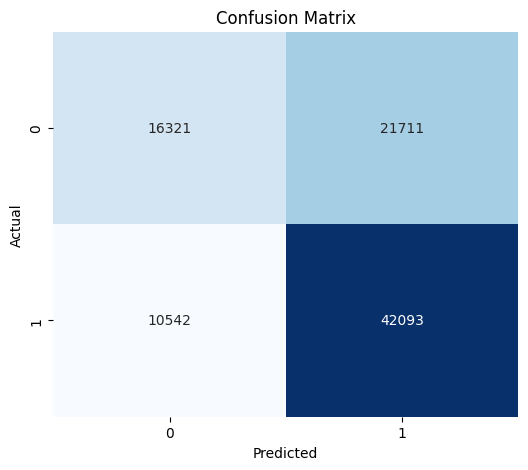

In [17]:
# 1. Retrieve the best parameters found by Optuna
best_params = study.best_params

# 2. Add the "fixed" parameters (GPU, objective, etc.) that we did not optimize
fixed_params = {
    'device_type': 'cpu', 
    'n_jobs': -1,
    'verbose': -1,
    'objective': 'binary',
    'metric': 'auc',
    'random_state': 42
}

# Merge the two dictionaries (fixed parameters + best found ones)
final_params = {**fixed_params, **best_params}

print(f"Training final model with parameters: {final_params}")

# 3. Final Training
# final_model = lgb.LGBMClassifier(**final_params)
final_model = xgb.XGBClassifier(**best_params, n_jobs=-1, random_state=42)
final_model.fit(X_train, y_train)

# 4. Evaluation
y_pred = final_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n--- Final Report ---")
print(f"Accuracy on the Test Set: {acc:.4f}")
print("\nPer-class details:")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix Plot (Great for presentations)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()